In [1]:
from huggingface_hub import login
from dotenv import load_dotenv
import os
import torch 

# load_dotenv('../../.env')
# HUGGINGFACE_TOKEN = os.environ['HUGGINGFACE_TOKEN']
# login(HUGGINGFACE_TOKEN)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Dataset

In [2]:
from datasets import load_dataset

dataset_name = "trl-lib/ultrafeedback_binarized"
dataset = load_dataset(dataset_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [3]:
train_dataset = dataset['train']
val_dataset = dataset['test']
train_dataset, val_dataset

(Dataset({
     features: ['chosen', 'rejected', 'score_chosen', 'score_rejected'],
     num_rows: 62135
 }),
 Dataset({
     features: ['chosen', 'rejected', 'score_chosen', 'score_rejected'],
     num_rows: 1000
 }))

## Tokenizer

In [4]:
from transformers import AutoTokenizer

model_name = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)

We tokenize user prompt, chosen and rejected text and we will apply padding on the fly.

In [5]:
def tokenize_function(example):
    
    user_prompt = example['chosen'][:1]
    prompt_tokens = tokenizer.apply_chat_template(user_prompt, return_tensors='pt')['input_ids']
    chosen_tokens = tokenizer.apply_chat_template(example['chosen'], return_tensors='pt')['input_ids']
    rejected_tokens = tokenizer.apply_chat_template(example['rejected'], return_tensors='pt')['input_ids']
    output = {
        'prompt_tokens': prompt_tokens, 
        'chosen_tokens': chosen_tokens, 
        'rejected_tokens': rejected_tokens,
        'chosen_tokens_length': chosen_tokens.shape[1],
        'rejected_tokens_length': rejected_tokens.shape[1]
    }
    return output


val_tokenized_dataset = val_dataset.map(
    tokenize_function,
    num_proc=os.cpu_count(),
    remove_columns=val_dataset.column_names
)

train_tokenized_dataset = train_dataset.map(
    tokenize_function,
    num_proc=os.cpu_count(),
    remove_columns=train_dataset.column_names
)

del train_dataset, val_dataset

## Model

In [22]:
from transformers import AutoModelForCausalLM


policy_model = AutoModelForCausalLM.from_pretrained(model_name)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Let's freeze the model weights and apply LoRA

In [23]:
import torch.nn as nn
import torch


class LoRALayer(nn.Module):
    def __init__(self, alpha: int, rank: int, input_dim: int, output_dim: int, dtype=torch.float32):
        super().__init__()
        self.alpha = alpha
        self.rank = rank
        self.A = nn.Parameter(torch.empty(input_dim, rank, dtype=dtype))
        self.B = nn.Parameter(torch.empty(rank, output_dim, dtype=dtype))
        nn.init.normal_(self.A, std=0.02)
        nn.init.zeros_(self.B)

    def forward(self, x):
        x = (self.alpha / self.rank) * (x @ self.A @ self.B)
        return x
    

class LinearWithLoRA(nn.Module):
    def __init__(self, linear: nn.Linear, alpha: int, rank: int, dtype):
        super().__init__()
        self.linear = linear
        input_dim = linear.weight.shape[1]
        output_dim = linear.weight.shape[0]
        self.lora_layer = LoRALayer(alpha, rank, input_dim, output_dim, dtype)

    def forward(self, x):
        x = self.linear(x) + self.lora_layer(x)
        return x

def replace_linear_with_lora(model, rank, alpha, model_dtype):
    for name, module in model.named_children():
        if isinstance(module, nn.Linear):
            # Replace the Linear layer with LinearWithLoRA
            setattr(model, name, LinearWithLoRA(module, rank=rank, alpha=alpha, dtype=model_dtype))
        else:
            # Recursively apply the same function to child modules
            replace_linear_with_lora(module, rank, alpha, model_dtype)

def replace_last_n_transformer_blocks_with_lora(model, rank, alpha, model_dtype, n_last_blocks=3):
    for module in model.model.layers[-n_last_blocks:]:
      replace_linear_with_lora(module, rank, alpha, model_dtype)

In [24]:
total_params = sum([p.numel() for p in policy_model.parameters()])
for p in policy_model.parameters():
    p.requires_grad_ = False

import copy

reference_model = copy.deepcopy(policy_model)
for p in reference_model.parameters():
    p.requires_grad_ = False

# apply LoRA to policy model
rank = 32
alpha = 16
replace_last_n_transformer_blocks_with_lora(model=policy_model, rank=rank, alpha=alpha, model_dtype=policy_model.dtype)
trainable_params = sum([p.numel() for p in policy_model.parameters() if p.requires_grad_])
print(f"Total parameters: {total_params:,} | Trainable parameters: {trainable_params:,}")

# move to GPU
policy_model.to(device)
reference_model.to(device)

Total parameters: 494,032,768 | Trainable parameters: 2,199,552


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

## DPO

In [25]:
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm.notebook import tqdm


class Trainer:
    def __init__(self, policy_model, reference_model, optimizer, loss_fn, max_steps: int, train_loader: DataLoader, val_loader: DataLoader, logger: SummaryWriter):
        
        self.policy_model = policy_model
        self.reference_model = reference_model
        
        self.optimizer = optimizer
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.max_steps = max_steps
        self.criterion = loss_fn

        self.logger = logger

    @staticmethod
    def compute_response_sequence_logprobs(model, tokens, attention_mask, response_mask):
        
        # compute raw logprobs
        logits = model(tokens, attention_mask=attention_mask).logits
        logprobs = F.log_softmax(logits, dim=-1) # (B, T, V)

        # shift to be able to compare predictions
        targets = tokens[:, 1:] # (B, T-1)
        response_mask = response_mask[:, 1:] # (B, T-1)
        logprobs = logprobs[:, :-1, :] # (B, T-1, V)

        # pick logprobs at each position
        token_logprobs = logprobs.gather(-1, targets.unsqueeze(-1)).squeeze(-1) # (B, T-1)

        # apply mask
        token_logprobs = token_logprobs * response_mask / response_mask.sum(dim=-1, keepdim=True).clamp_min(1) # (B, T-1)

        # compute mean per sequence
        token_logprobs = token_logprobs.mean(dim=-1)

        return token_logprobs

    def step_batch(self, batch):

        # move to GPU
        for k in batch.keys():
            batch[k] = batch[k].to(device)

        # compute logprobs
        policy_chosen_logprobs = self.compute_response_sequence_logprobs(
            model=self.policy_model,
            tokens=batch['chosen_tokens'],
            attention_mask=batch['chosen_mask'],
            response_mask=batch['chosen_response_mask']
        )
        policy_rejected_logprobs = self.compute_response_sequence_logprobs(
            model=self.policy_model,
            tokens=batch['rejected_tokens'],
            attention_mask=batch['rejected_mask'],
            response_mask=batch['rejected_response_mask']
        )

        with torch.no_grad():
            reference_chosen_logprobs = self.compute_response_sequence_logprobs(
                model=self.reference_model,
                tokens=batch['chosen_tokens'],
                attention_mask=batch['chosen_mask'],
                response_mask=batch['chosen_response_mask']
            )

            reference_rejected_logprobs = self.compute_response_sequence_logprobs(
                model=self.reference_model,
                tokens=batch['rejected_tokens'],
                attention_mask=batch['rejected_mask'],
                response_mask=batch['rejected_response_mask']     
            )

        # compute loss
        loss, logp_chosen, logp_rejected, reward_margin = self.criterion(policy_chosen_logprobs, policy_rejected_logprobs, reference_chosen_logprobs, reference_rejected_logprobs)
        
        # metrics
        metrics = {
            'loss': loss,
            'logp_chosen': logp_chosen,
            'logp_rejected': logp_rejected,
            'reward_margin': reward_margin,
            'accuracy': (logp_chosen > logp_rejected).float().mean()
        }
        return metrics

    def evaluate(self):
        metrics = {
            'loss': 0,
            'logp_chosen': 0,
            'logp_rejected': 0,
            'reward_margin': 0,
            'accuracy': 0
        }
        for batch in self.val_loader:
            batch_metrics = self.step_batch(batch)
            for metric_name, metric_value in batch_metrics.items():
                metrics[metric_name] += metric_value / len(self.val_loader)
        return metrics

    def train(self):
        
        for step in tqdm(range(self.max_steps), desc="Training"):

            iterator = iter(self.train_loader)

            try:
                batch = next(iterator)
            except StopIteration:
                iterator = iter(self.train_loader)
                batch = next(iterator)
            
            # remove old gradients
            self.optimizer.zero_grad()

            # compute train loss
            train_metrics = self.step_batch(batch)
            (train_metrics['loss']).backward()

            if step % 50 == 0:
                with torch.no_grad():
                    val_metrics = self.evaluate()
                # logging
                for metric_name, metric in val_metrics.items():
                    self.logger.add_scalar(f"Val/{metric_name.capitalize()}", metric.item(), step)
                    if "loss" in metric_name:
                        tqdm.write(f"Step: {step} | Val Loss: {metric}")
            
            # update weights
            self.optimizer.step()

            # logging
            for metric_name, metric in train_metrics.items():
                self.logger.add_scalar(f"Train/{metric_name.capitalize()}", metric.item(), step)
                if "loss" in metric_name:
                    tqdm.write(f"Step: {step} | Train Loss: {metric}")
            

class DPOLoss(nn.Module):

    def __init__(self, beta: float = 0.1):
        super().__init__()
        self.beta = beta

    def forward(self, policy_chosen_logprobs, policy_rejected_logprobs, reference_chosen_logprobs, reference_rejected_logprobs):
        logp_chosen = policy_chosen_logprobs - reference_chosen_logprobs
        logp_rejected = policy_rejected_logprobs - reference_rejected_logprobs
        logp_diff = logp_chosen - logp_rejected
        reward_margin = self.beta * logp_diff
        loss = - F.logsigmoid(reward_margin).mean()
        return loss, logp_chosen.mean(), logp_rejected.mean(), reward_margin.mean()
    

from torch.nn.utils.rnn import pad_sequence


def pad_tokens_plus_mask_creation(tokens, prompts_lens, pad_token_id):
    
    padded_tokens = pad_sequence(tokens, batch_first=True, padding_value=pad_token_id)
    attention_mask = (padded_tokens != pad_token_id).long()
    B, T = attention_mask.shape
    arange = torch.arange(T, device=attention_mask.device).unsqueeze(0)
    response_mask = (arange >= prompts_lens.unsqueeze(1)) & attention_mask.bool()
    response_mask = response_mask.long()
    return padded_tokens, attention_mask, response_mask


def custom_collate_fn(
    batch,
    pad_token_id=tokenizer.pad_token_id,
):
    """
    Expects batch as a list of dicts with torch tensors.
    Required keys per item: prompt_tokens, chosen_tokens, rejected_tokens
    """

    prompt_tokens = [item["prompt_tokens"].squeeze(0) for item in batch]
    chosen_tokens_list = [item["chosen_tokens"].squeeze(0) for item in batch]
    rejected_tokens_list = [item["rejected_tokens"].squeeze(0) for item in batch]

    prompt_lens = torch.tensor([t.shape[0] for t in prompt_tokens])

    chosen_tokens, chosen_mask, chosen_response_mask = pad_tokens_plus_mask_creation(chosen_tokens_list, prompts_lens=prompt_lens, pad_token_id=pad_token_id)
    rejected_tokens, rejected_mask, rejected_response_mask = pad_tokens_plus_mask_creation(rejected_tokens_list, prompts_lens=prompt_lens, pad_token_id=pad_token_id)

    batch_data = {
        "chosen_tokens": chosen_tokens,
        "rejected_tokens": rejected_tokens,
        "chosen_mask": chosen_mask,
        "rejected_mask": rejected_mask,
        "chosen_response_mask": chosen_response_mask,
        "rejected_response_mask": rejected_response_mask,
    }

    return batch_data


## Training

In [10]:
!nvidia-smi

Tue Mar 17 08:59:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   61C    P0             31W /   72W |    2180MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [11]:
import random
from torch.utils.data import Sampler


class TokenBudgetBatchSampler(Sampler):
    def __init__(self, chosen_lens, rejected_lens, max_tokens_per_batch, shuffle=True):
        self.chosen_lens = chosen_lens
        self.rejected_lens = rejected_lens
        self.max_tokens_per_batch = max_tokens_per_batch
        self.shuffle = shuffle

    def __iter__(self):
        idxs = list(range(len(self.chosen_lens)))
        if self.shuffle:
            random.shuffle(idxs)

        batch = []
        max_c = 0
        max_r = 0

        for i in idxs:
            c = self.chosen_lens[i]
            r = self.rejected_lens[i]

            new_max_c = max(max_c, c)
            new_max_r = max(max_r, r)
            new_B = len(batch) + 1

            # estimated padded tokens in batch
            est_tokens = new_B * (new_max_c + new_max_r)

            if batch and est_tokens > self.max_tokens_per_batch:
                yield batch
                batch = []
                max_c = 0
                max_r = 0
                # start new batch with current sample
                batch.append(i)
                max_c = c
                max_r = r
            else:
                batch.append(i)
                max_c = new_max_c
                max_r = new_max_r

        if batch:
            yield batch

    def __len__(self):
        # approximate
        return len(self.chosen_lens)


In [ ]:
# data loaders
train_token_budget = 6144
val_token_budget = 8192
train_tokenized_dataset.set_format('torch')
val_tokenized_dataset.set_format('torch')

train_chosen_length = train_tokenized_dataset[:]['chosen_tokens_length']
train_rejected_length = train_tokenized_dataset[:]['rejected_tokens_length']
train_sampler = TokenBudgetBatchSampler(
    chosen_lens=train_chosen_length, 
    rejected_lens=train_rejected_length, 
    max_tokens_per_batch=train_token_budget, 
    shuffle=True
)

val_tokenized_dataset = val_tokenized_dataset.select(range(10))
val_chosen_length = val_tokenized_dataset[:]['chosen_tokens_length']
val_rejected_length = val_tokenized_dataset[:]['rejected_tokens_length']
val_sampler = TokenBudgetBatchSampler(
    chosen_lens=val_chosen_length, 
    rejected_lens=val_rejected_length, 
    max_tokens_per_batch=val_token_budget, 
    shuffle=False
)

train_loader = DataLoader(train_tokenized_dataset, batch_sampler=train_sampler, collate_fn=custom_collate_fn, pin_memory=True, num_workers=2)
val_loader = DataLoader(val_tokenized_dataset, batch_sampler=val_sampler, collate_fn=custom_collate_fn)


6144.0

In [ ]:
from torch.optim import AdamW

# optimization
optimizer = AdamW(policy_model.parameters(), lr=3e-3)
max_steps = 30
criterion = DPOLoss()

# logging
experiment_name = "experiment_4"
logger = SummaryWriter(f"experiments/{experiment_name}")

trainer = Trainer(
    policy_model=policy_model,
    reference_model=reference_model,
    optimizer=optimizer,
    loss_fn=criterion,
    max_steps=max_steps,
    train_loader=train_loader,
    val_loader=val_loader,
    logger=logger
)

trainer.train()

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Step: 0 | Val Loss: 0.2080078125
Step: 0 | Train Loss: 0.69140625
Step: 1 | Train Loss: 0.6953125
Step: 2 | Train Loss: 0.69140625
Step: 3 | Train Loss: 0.69140625
Step: 4 | Train Loss: 0.69140625
Step: 5 | Train Loss: 0.69140625
Step: 6 | Train Loss: 0.6953125
Step: 7 | Train Loss: 0.69140625
Step: 8 | Train Loss: 0.69140625
Step: 9 | Train Loss: 0.6875
Step: 10 | Train Loss: 0.6953125
Step: 11 | Train Loss: 0.6875
Step: 12 | Train Loss: 0.69140625
Step: 13 | Train Loss: 0.69140625
Step: 14 | Train Loss: 0.69140625
Step: 15 | Train Loss: 0.703125
Step: 16 | Train Loss: 0.68359375
Step: 17 | Train Loss: 0.6875
Step: 18 | Train Loss: 0.6953125
Step: 19 | Train Loss: 0.6875


## Figures

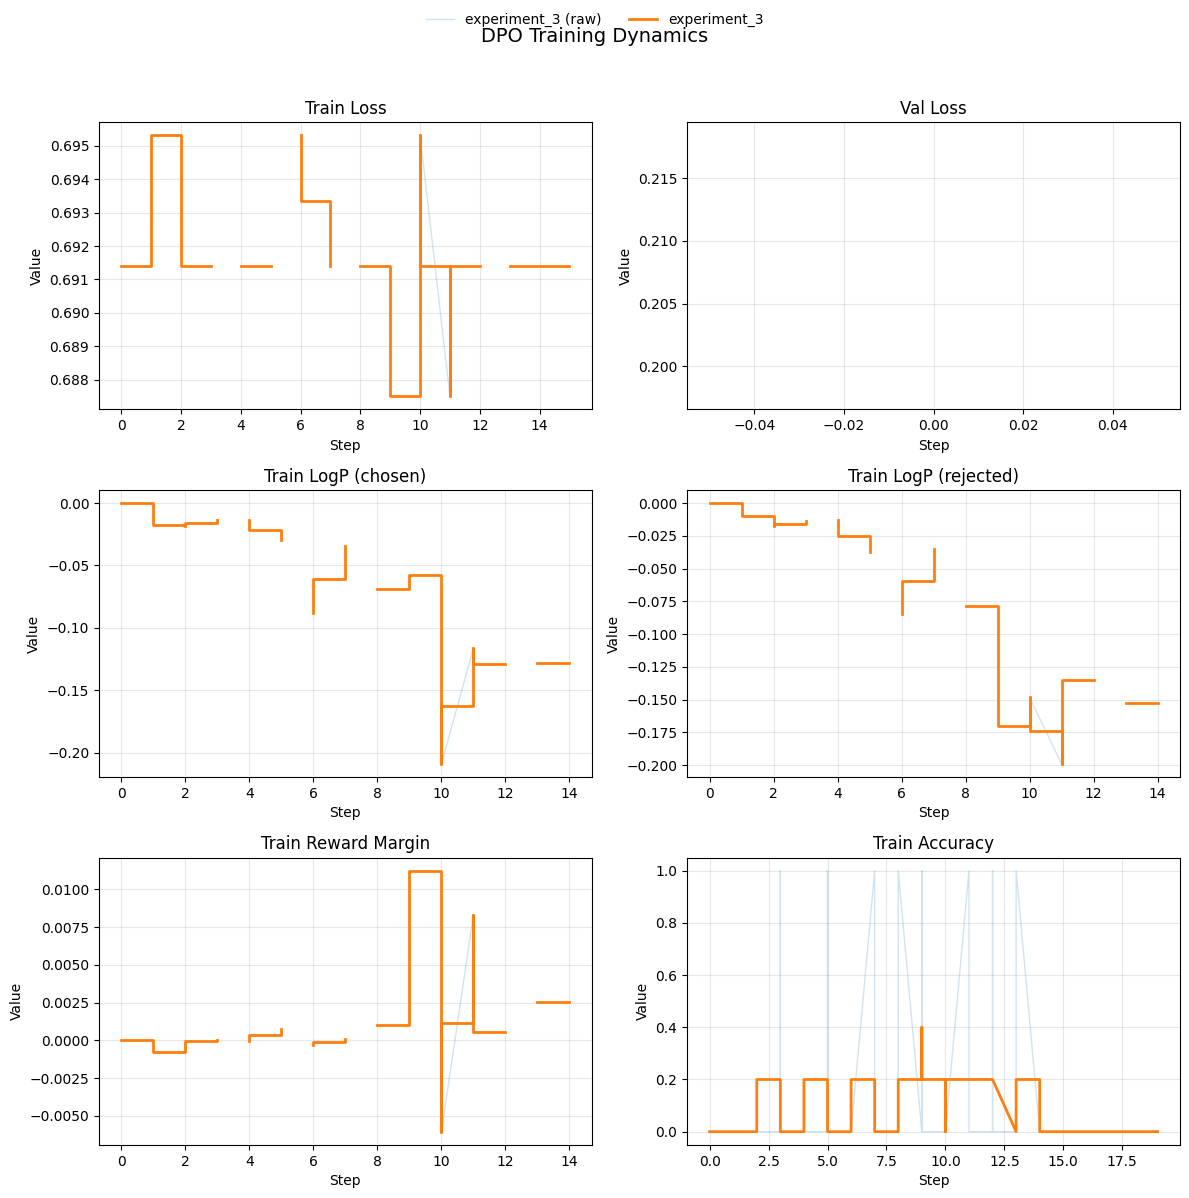

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import os


def _smooth_series(y, window):
    if window <= 1 or len(y) < window:
        return y
    return pd.Series(y).rolling(window=window, center=True, min_periods=1).mean().to_numpy()


def plot_tensorboard_logs(log_dirs, tags=None, smooth_window=25, show_raw=False):
    """
    DPO training plot grid for the metrics logged in this notebook.
    """
    if tags is None:
        tags = [
            'Train/Loss',
            'Val/Loss',
            'Train/Logp_chosen',
            'Train/Logp_rejected',
            'Train/Reward_margin',
            'Train/Accuracy',
        ]

    all_data = []
    for log_dir in log_dirs:
        experiment_name = os.path.basename(os.path.normpath(log_dir))
        if not os.path.exists(log_dir):
            print(f"Warning: Log directory '{log_dir}' not found. Skipping.")
            continue
        try:
            event_acc = EventAccumulator(log_dir)
            event_acc.Reload()
        except Exception as e:
            print(f"Error loading logs from '{log_dir}': {e}. Skipping.")
            continue

        for tag in tags:
            try:
                scalars = event_acc.Scalars(tag)
            except KeyError:
                continue
            df = pd.DataFrame({'step': [s.step for s in scalars], 'value': [s.value for s in scalars]})
            if df.empty:
                continue
            df['experiment'] = experiment_name
            df['tag'] = tag
            all_data.append(df)

    if not all_data:
        print("No data found for the given log directories/tags.")
        return

    data = pd.concat(all_data, ignore_index=True)

    fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=False)
    axes = axes.flatten()

    plot_specs = [
        ('Train/Loss', 'Train Loss', axes[0]),
        ('Val/Loss', 'Val Loss', axes[1]),
        ('Train/Logp_chosen', 'Train LogP (chosen)', axes[2]),
        ('Train/Logp_rejected', 'Train LogP (rejected)', axes[3]),
        ('Train/Reward_margin', 'Train Reward Margin', axes[4]),
        ('Train/Accuracy', 'Train Accuracy', axes[5]),
    ]

    for tag, title, ax in plot_specs:
        subset = data[data['tag'] == tag]
        if subset.empty:
            ax.set_title(f"{title} (missing)")
            ax.grid(True, alpha=0.3)
            continue

        for exp_name, df in subset.groupby('experiment'):
            df = df.sort_values('step')
            x = df['step'].to_numpy()
            y = df['value'].to_numpy()
            y_s = _smooth_series(y, smooth_window)

            if show_raw:
                ax.plot(x, y, alpha=0.2, linewidth=1, label=f"{exp_name} (raw)")
            ax.plot(x, y_s, linewidth=2, label=exp_name)

        ax.set_xlabel('Step')
        ax.set_title(title)
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
    fig.suptitle('DPO Training Dynamics', fontsize=14, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    fig.savefig("dpo_training_dynamics.png", dpi=300)
    plt.show()


plot_tensorboard_logs([f"experiments/{experiment_name}"], smooth_window=5, show_raw=True)
